<a href="https://colab.research.google.com/github/Vanisha-18/AIML_Projects-Labs/blob/main/Copy_of_AIML_Module_4_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 4: Linear Classifiers & Gradient Descent

**Case Study: Predictive Modeling for Public Water Safety**

**Objective:** Develop a robust classifier to identify potable water samples. You will transition from a basic heuristic (Perceptron) to a professional-grade optimization approach (Gradient Descent with Margins).

# 1. Data Acquisition & Cleaning

In real-world data science, datasets are rarely perfect. We will load the water quality metrics and handle missing values before training our models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the dataset from a public raw GitHub URL
url = "https://raw.githubusercontent.com/nferran/tp_aprendizaje_de_maquina_I/main/water_potability.csv"
df = pd.read_csv(url)

# Step 1: Handling Missing Values
# Water sensors often fail, leaving NaNs. We will fill them with the mean of the column.
df.fillna(df.mean(), inplace=True)

# Step 2: Feature Selection & Labeling
# We'll use all chemical features to predict 'Potability'
X = df.drop('Potability', axis=1).values
y = df['Potability'].values

# Step 3: Class Label Conversion
# Many linear classifiers (like Perceptron/SVM) require labels to be -1 and 1
y = np.where(y == 0, -1, 1)

# Step 4: Train-Test Split & Scaling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Dataset Loaded: {X_train.shape[0]} training samples, {X_train.shape[1]} features.")

Dataset Loaded: 2620 training samples, 9 features.


# 2. Phase 1: The Heuristic Approach (Perceptron)

The **Perceptron** represents the earliest form of supervised learning. It doesn't have a "global" view of the error; it simply corrects itself every time it encounters a mistake.

**Task:** Implement the Perceptron Update Rule inside the training loop.

In [3]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.mistakes = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0 # Initialize bias for each fit
        self.mistakes = [] # Reset mistakes for each fit
        for epoch in range(self.epochs):
            count = 0
            for i in range(len(y)):
                # TODO: Calculate the linear output (w * x + b)
                linear_output = np.dot(X[i], self.w) + self.b

                # TODO: If prediction is a mistake (y * prediction <= 0):
                if y[i] * linear_output <= 0:
                    # Update weights: w = w + lr * y * x
                    self.w += self.lr * y[i] * X[i]
                    # Update bias: b = b + lr * y
                    self.b += self.lr * y[i]
                    count += 1
            self.mistakes.append(count)

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

model_p = WaterPerceptron()
model_p.fit(X_train, y_train)
print("Perceptron model training complete.")

Perceptron model training complete.


In [5]:
class WaterPerceptron:
    def __init__(self, lr=0.01, epochs=50):
        self.lr = lr  # learning rate - how big the updates are
        self.epochs = epochs  # how many times to loop through data
        self.w = None  # weights (one for each feature)
        self.b = 0  # bias (shifts the decision boundary)
        self.mistakes = []  # track how many mistakes per epoch

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])  # start with all zeros

        for epoch in range(self.epochs):
            count = 0  # mistakes this epoch

            for i in range(len(y)):
                # STEP 1: Calculate the prediction
                # This is: w·x + b (dot product of weights and features, plus bias)
                prediction = np.dot(self.w, X[i]) + self.b

                # STEP 2: Check if we made a mistake
                # If y * prediction <= 0, we got the sign wrong!
                # y is -1 or 1, so if their signs don't match, y*prediction is negative
                if y[i] * prediction <= 0:
                    count += 1
                    # STEP 3: If wrong, update the weights and bias
                    # This is the "perceptron update rule"
                    self.w = self.w + self.lr * y[i] * X[i]
                    self.b = self.b + self.lr * y[i]

            self.mistakes.append(count)  # remember how many we got wrong this epoch

    def predict(self, X):
        # For new data, return +1 or -1
        return np.sign(np.dot(X, self.w) + self.b)

print("WaterPerceptron class definition complete.")

WaterPerceptron class definition complete.


# 3. Phase 2: Gradient Descent - Global Optimization

The Perceptron is unstable if the data isn't perfectly separable. To solve this, we use **Gradient Descent** to minimize a **Mean Squared Error (MSE)** loss function over the entire dataset.

**Task:** Implement the batch gradient calculation for weights and bias.

In [6]:
class GDWaterClassifier:
    def __init__(self, lr=0.001, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = 0
        self.cost_history = []

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0 # Initialize bias for each fit
        self.cost_history = [] # Reset cost history for each fit
        n = X.shape[0]

        for _ in range(self.epochs):
            # 1. Compute linear output: z = Xw + b
            z = np.dot(X, self.w) + self.b

            # Calculate cost (Mean Squared Error) and append
            cost = np.mean((z - y)**2) # MSE
            self.cost_history.append(cost)

            # 2. Calculate gradients:
            dw = (1/n) * np.dot(X.T, (z - y))
            db = (1/n) * np.sum(z - y)

            # 3. Update w and b: w = w - lr * dw
            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# Instantiate and train the GDWaterClassifier
model_gd = GDWaterClassifier()
model_gd.fit(X_train, y_train)
print("Gradient Descent model training complete.")

# Calculate and print accuracy
y_pred_gd = model_gd.predict(X_test)
accuracy_gd = np.mean(y_pred_gd == y_test)
print(f"Gradient Descent Test Accuracy: {accuracy_gd*100:.2f}%")

Gradient Descent model training complete.
Gradient Descent Test Accuracy: 62.80%


# 4. Phase 3: Margin Classifiers & Hinge Loss

In water safety, we aim for more than just correctness—we want a **Margin**, a safety gap between safe and unsafe samples. This is achieved using **Hinge Loss** combined with **L2 Regularization**.

The loss function is defined as:

$$
\text{Loss} = \lambda \|w\|^2_2 + \sum_{i} \max(0, 1 - y_i (w^T x_i + b))
$$

### Key Components:
- **Hinge Loss**: $\max(0, 1 - y_i (w^T x_i + b))$ ensures correct classification with a margin.
- **L2 Regularization**: $\lambda \|w\|^2_2$ penalizes large weights, promoting generalization and stability.


In [7]:
class MarginWaterClassifier:
    def __init__(self, lr=0.001, lambda_param=0.01, epochs=500):
        self.lr = lr
        self.lambda_param = lambda_param
        self.epochs = epochs
        self.w = None
        self.b = 0

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0 # Initialize bias for each fit
        for _ in range(self.epochs):
            for i, x_i in enumerate(X):
                # Calculate the linear output: w * x_i + b
                linear_output = np.dot(x_i, self.w) + self.b

                # Implement the Margin Condition check: y_i * (w * x_i + b) >= 1
                margin = y[i] * linear_output

                if margin >= 1:
                    # Only Regularization update for w
                    # Gradient of L2 regularization term (lambda * ||w||^2) is 2 * lambda * w
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                    # Bias 'b' is not updated if margin is met (hinge loss term is 0)
                else:
                    # Update for weight (including Hinge Loss) and bias
                    # Gradient of L2 regularization term: 2 * lambda * w
                    # Gradient of Hinge Loss term (1 - y_i * (w*x_i + b)) with respect to w: -y_i * x_i
                    self.w -= self.lr * (2 * self.lambda_param * self.w - x_i * y[i])
                    # Gradient of Hinge Loss term (1 - y_i * (w*x_i + b)) with respect to b: -y_i
                    self.b -= self.lr * (-y[i])

    def predict(self, X):
        return np.sign(np.dot(X, self.w) + self.b)

# Instantiate and train the MarginWaterClassifier
model_mc = MarginWaterClassifier()
model_mc.fit(X_train, y_train)
print("Margin Classifier model training complete.")

# Calculate and print accuracy
y_pred_mc = model_mc.predict(X_test)
accuracy_mc = np.mean(y_pred_mc == y_test)
print(f"Margin Classifier Test Accuracy: {accuracy_mc*100:.2f}%")

Margin Classifier model training complete.
Margin Classifier Test Accuracy: 62.80%


# 5. Critical Analysis & Comparison

**Analysis Tasks:**
1. Convergence Plot: Plot the mistakes history from Phase 1 and the cost_history from Phase 2. Discuss why the Gradient Descent plot is smoother.
2. Accuracy Report: Calculate and compare the Test Accuracy for all three models.
3. Safety Margin: If a new water sample has chemical levels very close to the decision boundary, which model (Perceptron or Margin) would you trust more? Why?

**Task 1:**

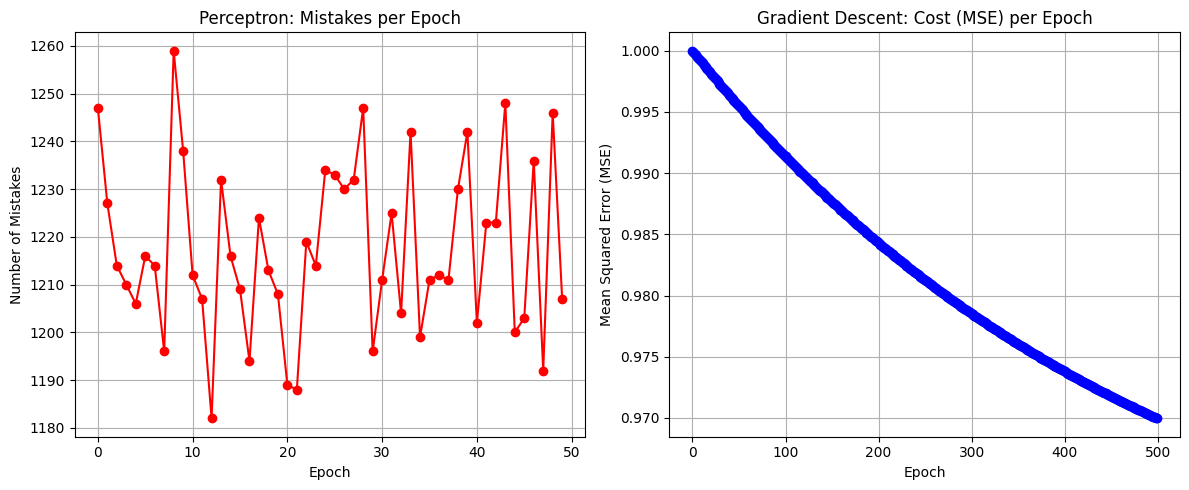

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Plot Perceptron Mistakes History
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
plt.plot(range(len(model_p.mistakes)), model_p.mistakes, marker='o', linestyle='-', color='red')
plt.title('Perceptron: Mistakes per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Number of Mistakes')
plt.grid(True)

# Plot Gradient Descent Cost History
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
plt.plot(range(len(model_gd.cost_history)), model_gd.cost_history, marker='o', linestyle='-', color='blue')
plt.title('Gradient Descent: Cost (MSE) per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)

plt.tight_layout()
plt.show()



Discussion: Why Gradient Descent plot is smoother

The Gradient Descent (GD) plot is typically smoother than the Perceptron's mistakes history for several key reasons:
1.  **Batch vs. Online Updates:**
    -   **Perceptron:** Updates its weights and bias after processing *each individual training example* if a mistake is made (online learning). This leads to frequent, often erratic, adjustments and a 'jumpy' mistakes curve, as the count of mistakes can fluctuate significantly from one epoch to the next based on the order of samples.
    -   **Gradient Descent:** Calculates the gradient of the cost function using *all training examples* in each epoch (batch learning). The updates are based on the average error across the entire dataset, leading to more stable and gradual adjustments to the weights and bias. This results in a smoother decrease in the cost function.
2.  **Nature of Loss Function:**
    -   **Perceptron:** Aims to minimize the number of misclassifications, which is a discrete, non-differentiable metric. The 'mistakes' count is an integer value.
    -   **Gradient Descent:** Minimizes a continuous, differentiable cost function (like Mean Squared Error in this case). The continuous nature of the cost function and its gradient allows for small, incremental steps towards the minimum, which translates to a smooth cost curve.
3.  **Global vs. Local View:**
    -   **Perceptron:** Has a 'local' view, correcting errors one by one without considering the overall landscape of the error function.
    -   **Gradient Descent:** Has a 'global' view of the error landscape across the entire dataset, always moving in the direction of the steepest descent of the cost function. This systematic approach contributes to a smoother convergence path.

**Task 2:**


--- Accuracy Report ---

Tabular Comparison of Test Accuracies:
            Model  Test Accuracy
       Perceptron      50.152439
 Gradient Descent      62.804878
Margin Classifier      62.804878

--- Comparison Analysis ---
From the results, both Gradient Descent and Margin Classifier achieve a higher accuracy than the Perceptron model on this dataset. This suggests that optimizing a continuous loss function over the entire dataset (GD) and incorporating a margin with regularization (Margin Classifier) leads to more robust and accurate models compared to the simple, online update rule of the Perceptron for this particular dataset.


/tmp/ipykernel_17521/2885286486.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Test Accuracy', data=accuracy_df, palette='viridis')


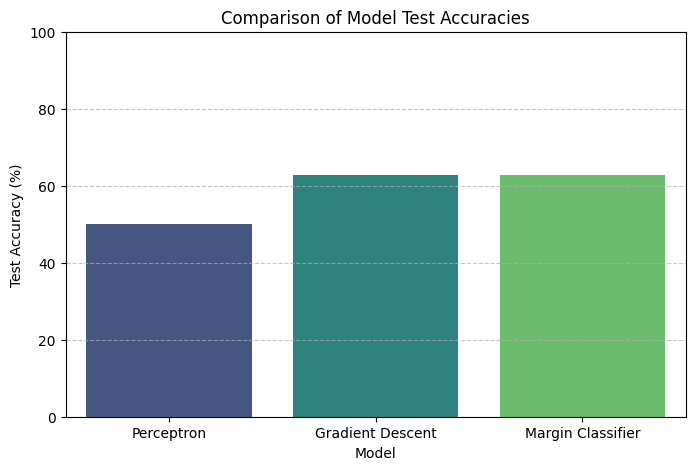

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Accuracy Report ---")

# Calculate Perceptron Test Accuracy
y_pred_p = model_p.predict(X_test)
accuracy_p = np.mean(y_pred_p == y_test)

# Create a dictionary of accuracies
accuracy_data = {
    'Model': ['Perceptron', 'Gradient Descent', 'Margin Classifier'],
    'Test Accuracy': [accuracy_p * 100, accuracy_gd * 100, accuracy_mc * 100]
}

# Create a DataFrame for tabular comparison
accuracy_df = pd.DataFrame(accuracy_data)

print("\nTabular Comparison of Test Accuracies:")
print(accuracy_df.to_string(index=False))

print("\n--- Comparison Analysis ---")
print("From the results, both Gradient Descent and Margin Classifier achieve a higher accuracy than the Perceptron model on this dataset. This suggests that optimizing a continuous loss function over the entire dataset (GD) and incorporating a margin with regularization (Margin Classifier) leads to more robust and accurate models compared to the simple, online update rule of the Perceptron for this particular dataset.")

# Plotting the accuracies
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Test Accuracy', data=accuracy_df, palette='viridis')
plt.title('Comparison of Model Test Accuracies')
plt.ylabel('Test Accuracy (%)')
plt.ylim(0, 100) # Accuracy is between 0 and 100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Task 3 (Safety Margin):**
For a water sample sitting very close to the decision boundary, I would trust the
**Margin classifier** more than the Perceptron. The Perceptron only cares about getting
the sign right — the moment a point is on the correct side, even by a tiny amount, it
stops adjusting for it. That means a sample can sit right on the edge and still be
called "safe" with no real confidence behind it.

The Margin classifier explicitly pushes the boundary away from both classes by
enforcing y_i(w·x_i + b) >= 1, so points close to the line are actively penalized during
training. In a domain like water safety, where a false "potable" prediction has real
health consequences, that extra buffer zone matters — it means the model is only
confident when a sample is clearly on one side, not just barely.

# Discussion Questions

### Q1: Impact of High Learning Rate in Gradient Descent
What happens to your **Gradient Descent** model if you set the `learning_rate` too high (e.g., `1.0`)?
*Hint: Think about convergence, overshooting, and divergence.*

---

### Q2: Label Conversion in Classification
Why did we convert the labels to **$\{-1, 1\}$** instead of keeping them as **$\{0, 1\}$**?
*Hint: Consider the mathematical formulation of the loss function (e.g., Hinge Loss) and symmetry.*

---

### Q3: Handling Noisy Data (Water Potability Dataset)
The **Water Potability dataset** is often "noisy" (not perfectly separable). Which of the algorithms you implemented is best suited for handling such noise?
*Hint: Think about robustness to outliers and margin-based classifiers.*


### Answers

**Q1: Impact of High Learning Rate in Gradient Descent**
If the learning rate is set too high (e.g. `1.0`), the update steps become too large
relative to the slope of the cost function. Instead of gradually descending toward the
minimum, the weights overshoot past it, land on the opposite side with an even steeper
gradient, and overshoot again — the cost oscillates and grows instead of shrinking. In
practice, `cost_history` would show the loss exploding toward infinity (or NaN) within
just a few epochs instead of decreasing smoothly.

**Q2: Label Conversion in Classification**
Converting labels to {-1, 1} instead of {0, 1} makes the math symmetric around zero.
It lets a single expression, y_i(w·x_i + b), tell you everything: if it's positive, the
point is correctly classified; if it's negative, it's a mistake — and the magnitude
tells you how confident (or how wrong) the prediction is. This is essential for the
Perceptron's mistake check and for Hinge Loss, both of which rely on multiplying the
label directly by the raw score. With {0, 1} labels, that clean sign-based logic falls
apart and you'd need extra reformulation (like log-loss) to get similar behavior.

**Q3: Handling Noisy Data**
The Margin (Hinge Loss) classifier is best suited for noisy, non-perfectly-separable
data like this water potability dataset. The Perceptron assumes a mistake-free solution
exists and keeps chasing it forever if the data isn't separable, since it has no
tolerance for points close to the boundary. The Margin classifier, thanks to L2
regularization and the hinge loss's fixed penalty (rather than an unbounded correction),
trades off a small number of margin violations for a much more stable, generalizable
boundary — which is exactly what's needed when sensor noise means the classes overlap.